In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut

# Load results from signal processing pipeline
df = pd.read_csv(r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\values\drone_noise_results.csv")
print(df)

    RPM  Expected_BPF_Hz  Measured_BPF_Hz  SPL_at_BPF_dB
0  2250            75.00            74.19          25.42
1  2950            98.33            97.24          26.72
2  3000           100.00            97.24          29.04
3  3600           120.00           117.29          29.83
4  4500           150.00           151.38          40.82
5  5700           190.00           189.47          49.23


In [6]:
# Features: what we can measure from the spectrum
# Target: RPM

X = df[['Measured_BPF_Hz', 'SPL_at_BPF_dB']].values
y = df['RPM'].values

print("Features (Measured_BPF_Hz, SPL_at_BPF_dB):")
print(X)
print("\nTarget (RPM):")
print(y)

Features (Measured_BPF_Hz, SPL_at_BPF_dB):
[[ 74.19  25.42]
 [ 97.24  26.72]
 [ 97.24  29.04]
 [117.29  29.83]
 [151.38  40.82]
 [189.47  49.23]]

Target (RPM):
[2250 2950 3000 3600 4500 5700]


In [7]:
loo = LeaveOneOut()

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    predictions = []
    actuals = []
    
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        predictions.append(pred[0])
        actuals.append(y_test[0])
    
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    print(f"{name}: MAE = {mae:.1f} RPM, R² = {r2:.3f}")

Linear Regression: MAE = 57.3 RPM, R² = 0.997
Random Forest: MAE = 564.0 RPM, R² = 0.557


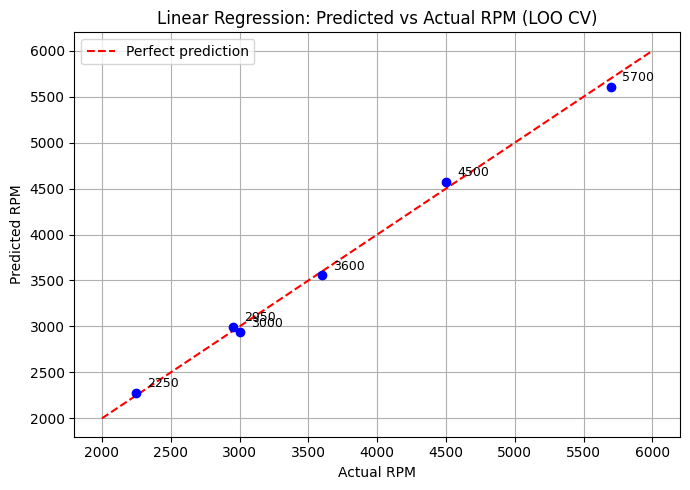

In [8]:
# Cell 4 — Predicted vs Actual plot
lr = LinearRegression()
loo_preds = []

for train_idx, test_idx in loo.split(X):
    lr.fit(X[train_idx], y[train_idx])
    loo_preds.append(lr.predict(X[test_idx])[0])

plt.figure(figsize=(7, 5))
plt.scatter(y, loo_preds, color='blue', zorder=5)
plt.plot([2000, 6000], [2000, 6000], 'r--', label='Perfect prediction')
for i, rpm in enumerate(y):
    plt.annotate(f'{rpm}', (rpm, loo_preds[i]), 
                textcoords="offset points", xytext=(8,4), fontsize=9)
plt.xlabel('Actual RPM')
plt.ylabel('Predicted RPM')
plt.title('Linear Regression: Predicted vs Actual RPM (LOO CV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig4_ml_regression.png', dpi=150)
plt.show()

In [9]:
# Cell 5 — Which feature matters more?
lr_full = LinearRegression()
lr_full.fit(X, y)

print("Linear Regression Coefficients:")
print(f"  Measured_BPF_Hz: {lr_full.coef_[0]:.3f}")
print(f"  SPL_at_BPF_dB:   {lr_full.coef_[1]:.3f}")
print(f"  Intercept:        {lr_full.intercept_:.3f}")

Linear Regression Coefficients:
  Measured_BPF_Hz: 31.869
  SPL_at_BPF_dB:   -10.775
  Intercept:        167.267
